# 📊 Telco Customer Churn - Comprehensive Exploratory Data Analysis (EDA)

**Objective:** Uncover key churn drivers, expose hidden data traps (like whitespace strings in `TotalCharges`), understand class imbalance, and extract actionable business retention insights.

### 1. Import Libraries and Set Styles

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Visual configurations
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print('Libraries imported successfully!')

Libraries imported successfully!


### 2. Load Dataset & Inspect Structure

In [2]:
df = pd.read_csv('../Data/Raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset Shape: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 3. Data Cleaning & Fixing the 'TotalCharges' Trap
Notice that `TotalCharges` is stored as an `object` (string) instead of a `float`. This happens because new customers (`tenure = 0`) have blank spaces `' '` instead of numerical values!

In [4]:
# Check how many blank strings exist in TotalCharges
blank_count = (df['TotalCharges'] == ' ').sum()
print(f'Number of blank spaces in TotalCharges: {blank_count}')

# Convert TotalCharges to numeric, turning blank spaces into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check where tenure == 0
print('Rows with NaN in TotalCharges (tenure check):')
display(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']])

# Fill NaN with 0.0 (since tenure is 0 months, total charges incurred is 0)
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)
print('TotalCharges successfully cleaned and converted to float!')

Number of blank spaces in TotalCharges: 11
Rows with NaN in TotalCharges (tenure check):


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


TotalCharges successfully cleaned and converted to float!


### 4. Target Variable Analysis: Class Imbalance
Let's inspect how skewed our target variable `Churn` is.

Churn Distribution:
  No: 5174 (73.46%)
  Yes: 1869 (26.54%)


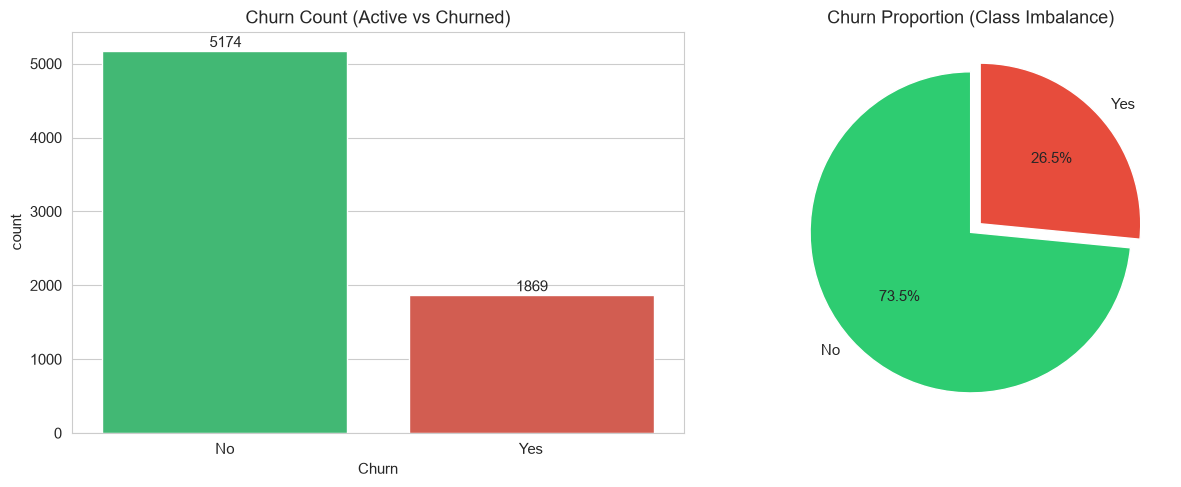

In [5]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('Churn Distribution:')
for val, cnt in churn_counts.items():
    print(f'  {val}: {cnt} ({churn_pct[val]:.2f}%)')

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(x='Churn', data=df, palette=['#2ecc71', '#e74c3c'], ax=ax[0])
ax[0].set_title('Churn Count (Active vs Churned)')
for p in ax[0].patches:
    ax[0].annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 50))

ax[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0, 0.08))
ax[1].set_title('Churn Proportion (Class Imbalance)')
plt.tight_layout()
plt.show()

💡 **Key Takeaway:** ~73.5% active vs ~26.5% churned. A naive model that predicts 'No' for everyone would get 73.5% accuracy but catch 0 churners. We must optimize for **Recall & ROC-AUC / PR-AUC**!

### 5. Numerical Features Analysis (`tenure`, `MonthlyCharges`, `TotalCharges`)

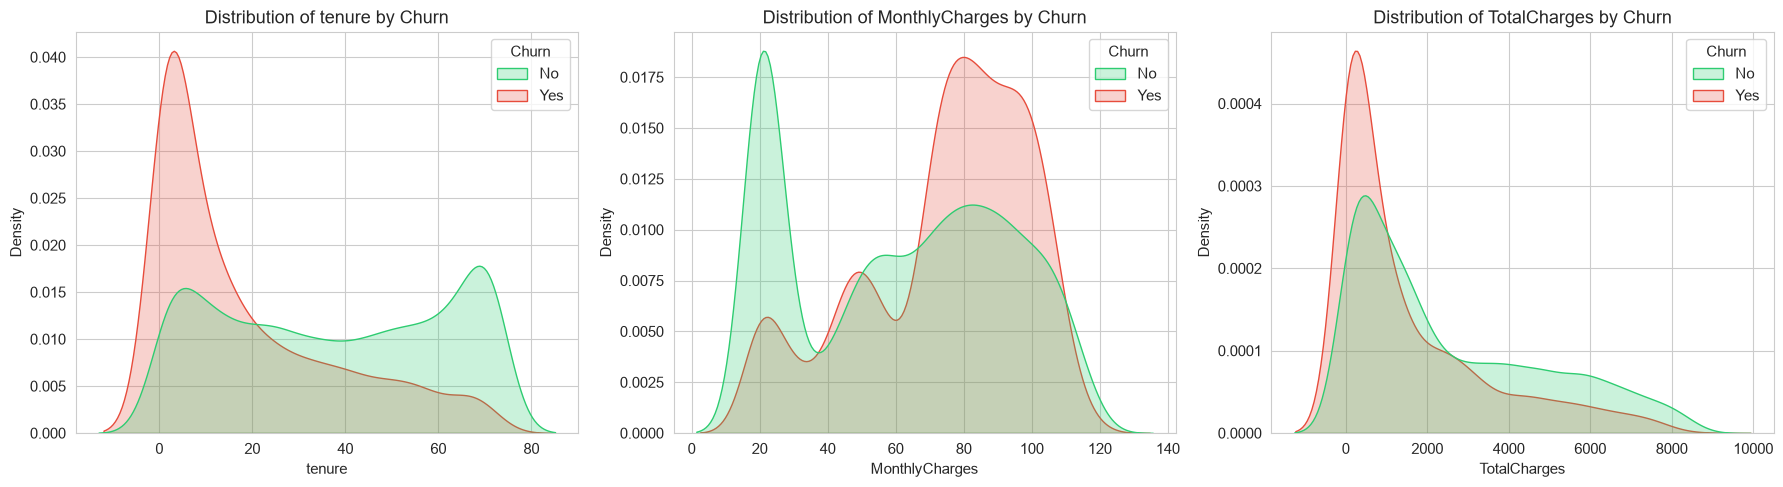

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False, palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by Churn')

plt.tight_layout()
plt.show()

💡 **Numerical Insights:**
1. **Tenure:** Extreme spike in churn for customers with tenure < 6 months. High risk period is the onboarding phase!
2. **MonthlyCharges:** Customers paying higher monthly fees ($70 - $105) have drastically higher churn.
3. **TotalCharges:** Churned customers have low total charges because they leave early.

### 6. Contract Type & Payment Method Analysis (The Strongest Drivers)

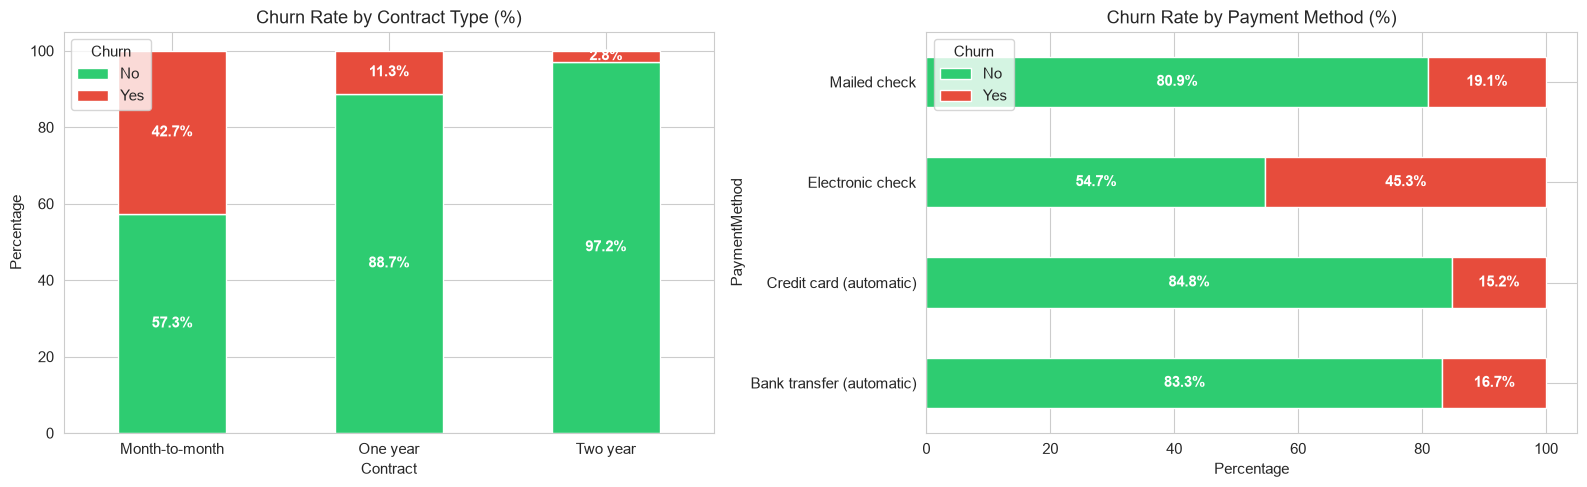

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Contract vs Churn
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[0], rot=0)
axes[0].set_title('Churn Rate by Contract Type (%)')
axes[0].set_ylabel('Percentage')
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontweight='bold')

# Payment Method vs Churn
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
payment_churn.plot(kind='barh', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Churn Rate by Payment Method (%)')
axes[1].set_xlabel('Percentage')
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

💡 **Contract & Payment Insights:**
- **Month-to-Month:** 42.7% churn rate! Huge flight risk.
- **Two-Year Contract:** Only 2.8% churn rate! Long term lock-in drastically increases loyalty.
- **Electronic Check:** 45.3% churn rate! Automatic credit card and bank transfer customers are significantly more loyal.

### 7. Tech Services & Security Add-ons Analysis

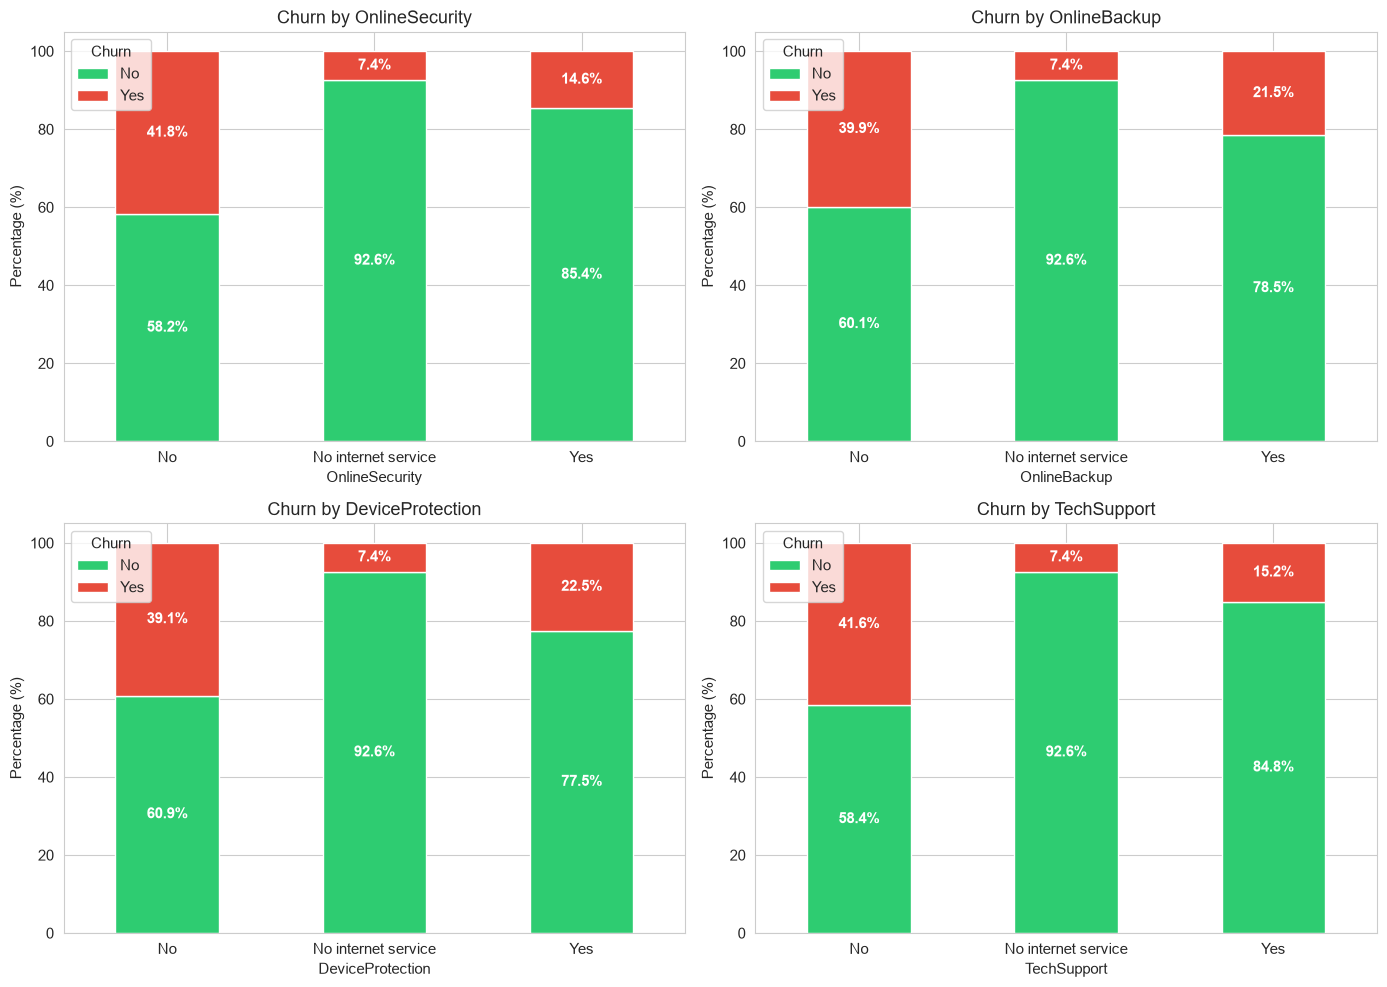

In [8]:
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, service in enumerate(services):
    srv_churn = pd.crosstab(df[service], df['Churn'], normalize='index') * 100
    srv_churn.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[i], rot=0)
    axes[i].set_title(f'Churn by {service}')
    axes[i].set_ylabel('Percentage (%)')
    for c in axes[i].containers:
        axes[i].bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

💡 **Service Insights:**
- Customers with **NO Online Security** or **NO Tech Support** churn at **~41.7%**.
- Customers WITH Tech Support churn at only **15.2%**! Offering free 3-month tech support is a golden retention intervention.

### 8. Senior Citizens & Internet Service Type

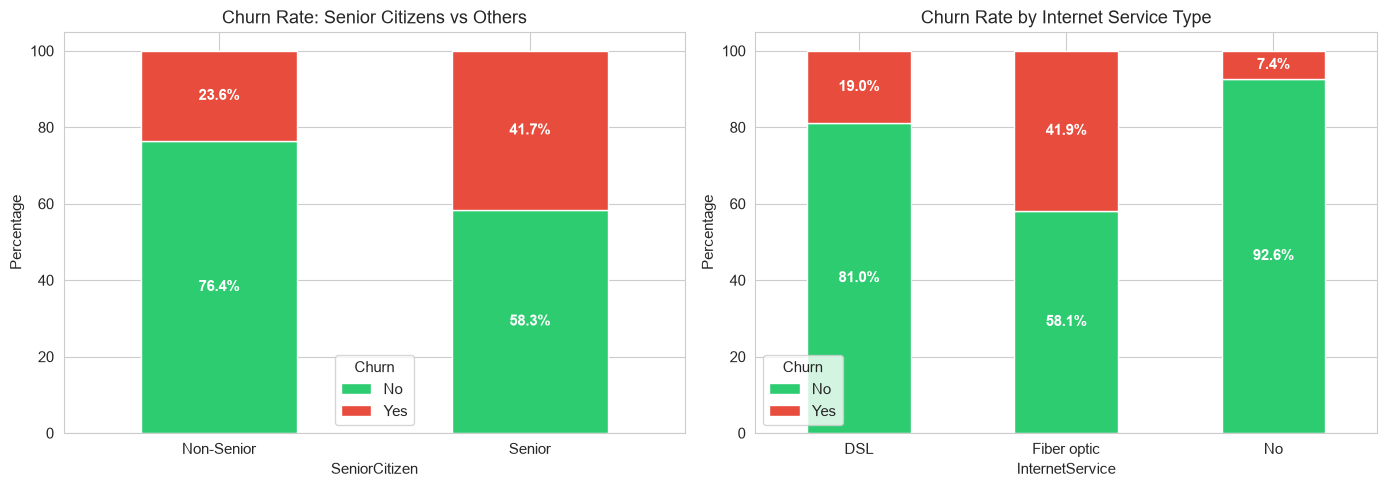

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Senior Citizen
senior_churn = pd.crosstab(df['SeniorCitizen'].map({0: 'Non-Senior', 1: 'Senior'}), df['Churn'], normalize='index') * 100
senior_churn.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[0], rot=0)
axes[0].set_title('Churn Rate: Senior Citizens vs Others')
axes[0].set_ylabel('Percentage')
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontweight='bold')

# Internet Service
net_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
net_churn.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[1], rot=0)
axes[1].set_title('Churn Rate by Internet Service Type')
axes[1].set_ylabel('Percentage')
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

💡 **Demographic & Service Type Insights:**
- **Fiber Optic** customers churn at **41.9%**, vs DSL (18.9%) and No Internet (7.4%).
- **Senior Citizens** churn at **41.7%** (nearly 2x higher than non-seniors).

### 9. Feature Correlation Heatmap with Target

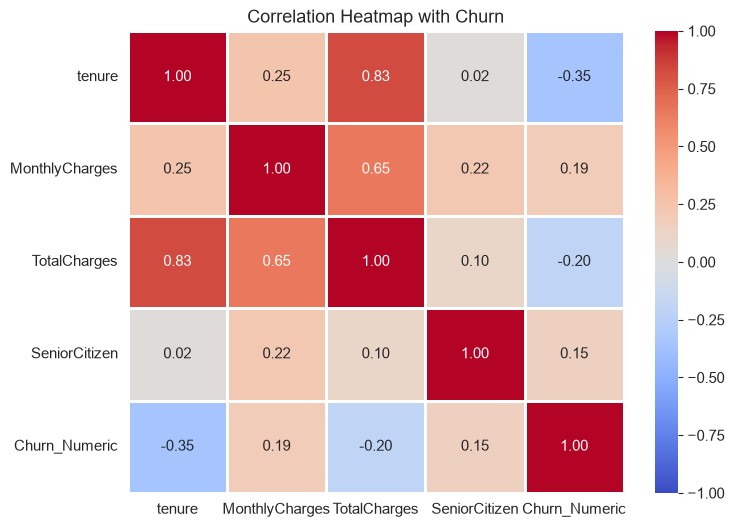

In [10]:
df_corr = df.copy()
df_corr['Churn_Numeric'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})
num_features = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_Numeric']]

plt.figure(figsize=(8, 6))
sns.heatmap(num_features.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=1)
plt.title('Correlation Heatmap with Churn')
plt.show()

### 10. Summary of Key Architectural Decisions for Production Pipeline
1. **Drop `customerID`**: Unique ID, zero predictive value.
2. **Numeric Pipeline**: Impute missing with `median` (specifically to catch empty spaces in `TotalCharges`), Standard Scale `['tenure', 'MonthlyCharges', 'TotalCharges']`.
3. **Categorical Pipeline**: One-Hot Encode `['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']`.
4. **Target Encoding**: `Churn` -> `{'Yes': 1, 'No': 0}`.
5. **Stratified Split**: Must use `StratifiedShuffleSplit` / `stratify=y` so both train and test have identical 73.5% : 26.5% ratio.
6. **Model Selection & Imbalance Strategy**: Train classifiers with `class_weight='balanced'` and evaluate with ROC-AUC & Recall/F1.